# Clase 3 — Transformers para Visión Computacional (ViT)

<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Google Colab"/></a>

> Para usarlo en Google Colab: sube este notebook a Colab o guárdalo en Drive y ábrelo desde `Archivo > Abrir notebook`.

Sorpresa: el **mismo** Transformer de las Clases 1 y 2 —pensado para texto— funciona en **imágenes** casi sin cambios. Solo hay que decidir **qué es un token** en una imagen. Esta clase construye el **Vision Transformer (ViT)** y sus variantes.

**Objetivos.** Al terminar deberías poder:
1. Explicar por qué tratar cada píxel como token **no escala**, y cómo los **parches** lo resuelven.
2. Describir el pipeline **ViT**: parches → proyección → positional embedding → token `[CLS]` → clasificación.
3. Comparar **ViT vs. CNN/ResNet**: sesgo inductivo, necesidad de datos y pre-entrenamiento.
4. Conocer mejoras (**regularización/aumentación**, **destilación/DeiT**) y el ViT **jerárquico (Swin)**.
5. Implementar el *patch embedding* y un mini-ViT, y visualizar mapas de atención de un ViT preentrenado.

**Formato (≈ 3 horas):** teoría + práctica. Activa **GPU**.

| Bloque | Tema | ~min |
|---|---|---|
| 0 | La imagen como secuencia: el problema de memoria | 15 |
| 1 | Vision Transformer (ViT) | 30 |
| 2 | ViT vs. ResNets: sesgo inductivo y datos | 20 |
| — | *Descanso* | 10 |
| 3 | Mejorando ViT + ViT jerárquico (Swin) | 30 |
| 4 | 🧪 Práctica: patch embedding, mini-ViT y atención | 55 |

## Bloque 0 · La imagen como secuencia

In [ ]:
# Setup
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
!pip install -q dlviz transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.3 MB/s eta 0:00:00


La idea más ingenua: tratar cada **píxel** como un token y alimentar un Transformer estándar. **Problema: la memoria.** La matriz de atención es cuadrática en el número de tokens. Una imagen de $R\times R$ píxeles necesita $R^4$ entradas por matriz de atención.

> Para $R=128$, 48 capas y 16 cabezas: **~768 GB** solo para las matrices de atención de **una** imagen. Inviable.

La solución del ViT: no usar píxeles como tokens, sino **parches** (por ejemplo, bloques de $16\times16$).

In [ ]:
# Demo: la explosión cuadrática — píxeles vs parches
def coste_atencion(n_tokens): return n_tokens**2
R = 224
print(f"Imagen {R}x{R}:")
print(f"  como píxeles  -> {R*R:,} tokens -> matriz de atención de {coste_atencion(R*R):,} entradas")
P = 16; n = (R//P)**2
print(f"  como parches {P}x{P} -> {n} tokens -> matriz de {coste_atencion(n):,} entradas")
print(f"  reducción: {coste_atencion(R*R)/coste_atencion(n):,.0f}x menos")

Imagen 224x224:
  como píxeles  -> 50,176 tokens -> matriz de atención de 2,517,630,976 entradas
  como parches 16x16 -> 196 tokens -> matriz de 38,416 entradas
  reducción: 65,536x menos


## Bloque 1 · Vision Transformer (ViT)

El **ViT** (Dosovitskiy et al., 2020) aplica el Transformer a imágenes en cuatro pasos:

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m2_11_vit_parches.png" width="620">

<sub>Paso 1: dividir la imagen en N parches (p. ej. 16x16) y aplanarlos.</sub>

1. **Trocear** la imagen en $N$ parches de tamaño fijo (p. ej. $3\times16\times16$).
2. **Proyectar** cada parche a un vector de $D$ dimensiones (una capa lineal — implementada como una `Conv2d`).
3. Sumar un **positional embedding** (la atención no conoce el orden — igual que en texto).
4. Añadir un **token `[CLS]`** aprendible; su salida, tras el Transformer, se proyecta a las **clases**.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m2_10_vit_arquitectura.png" width="720">

<sub>Pipeline completo del ViT: parches → proyección → [+pos, +CLS] → Transformer (el mismo de NLP) → clasificación.</sub>

La única "novedad" respecto al Transformer de texto es la **primera capa** (parches → embeddings, una `Conv2d`). El resto es *idéntico*. Fíjate en la conexión con la Clase 1: el patrón `[CLS] + Transformer + cabeza lineal` es el que ya implementaste en el Ejercicio 2.

## Bloque 2 · ViT vs. ResNets: sesgo inductivo y datos

Una CNN trae incorporado un fuerte **sesgo inductivo**: la convolución asume *localidad* e *invarianza a traslación*. El ViT **no**: aprende esas relaciones desde cero, vía atención. Esto tiene una consecuencia clara en los datos que necesita:

- Entrenado solo en **ImageNet-1k** (1.2M imágenes), el ViT **no supera** a las ResNets.
- Pre-entrenado en **ImageNet-21k** (14M) alcanza a las ResNets grandes.
- Pre-entrenado en **JFT-300M** (300M), el ViT **supera** a las ResNets — y usa el cómputo de forma más eficiente.

> **La lección:** el ViT tiene *menos sesgo inductivo*, así que **necesita más datos** para pre-entrenar. Pero a gran escala, esa flexibilidad gana.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m2_08_feature_hierarchy.png" width="640">

<sub>Una CNN reduce la resolución y aumenta la profundidad por etapas; en un ViT clásico todos los bloques mantienen la misma resolución.</sub>

## Bloque 3 · Mejorando ViT y el ViT jerárquico

**Regularización + aumentación.** Como el ViT tiene poco sesgo inductivo, la **regularización** (weight decay, dropout) y la **aumentación** (MixUp, RandAugment) ayudan mucho — más que en una CNN.

**Destilación (DeiT).** Entrenar un ViT *estudiante* para imitar a una CNN *teacher* mejora bastante el rendimiento con menos datos. Es una forma de transferir el sesgo inductivo de la CNN al ViT.

**ViT jerárquico (Swin).** El ViT clásico mantiene la misma resolución en todos los bloques; una CNN, en cambio, construye una **jerarquía** (más resolución → menos, más canales). **Swin Transformer** recupera esa jerarquía y, sobre todo, resuelve el coste cuadrático con **window attention**: en vez de atención global, se calcula atención dentro de **ventanas** locales de $M\times M$ tokens (coste **lineal**). Para comunicar ventanas, alterna ventanas normales y **desplazadas** (*shifted windows*) entre bloques.

> Estas ideas (jerarquía + atención local) hacen a los ViT competitivos en **detección** y **segmentación**, no solo clasificación. **DETR** usa un encoder-decoder Transformer para detección de objetos como predicción directa de un *conjunto* de cajas.

## Bloque 4 · 🧪 Práctica

Tres partes: (A) implementar el **patch embedding** desde cero, (B) armar y entrenar un **mini-ViT** en MNIST, y (C) cargar un **ViT preentrenado** y **visualizar su atención**.

### A · Patch embedding desde cero

In [ ]:
# Patch embedding: trocear la imagen y proyectar cada parche a D dimensiones.
# El truco: una Conv2d con kernel=stride=patch_size hace exactamente esto.
class PatchEmbed(nn.Module):
    def __init__(self, img_size=28, patch=7, in_ch=1, dim=64):
        super().__init__()
        self.n_patches = (img_size // patch) ** 2
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
    def forward(self, x):                     # x: (B, C, H, W)
        x = self.proj(x)                      # (B, dim, H/p, W/p)
        return x.flatten(2).transpose(1, 2)   # (B, n_patches, dim)

pe = PatchEmbed()
dummy = torch.randn(4, 1, 28, 28)             # 4 imágenes 28x28 (estilo MNIST)
print("entrada:", tuple(dummy.shape), "-> parches:", tuple(pe(dummy).shape),
      f"({pe.n_patches} parches por imagen)")

entrada: (4, 1, 28, 28) -> parches: (4, 16, 64) (16 parches por imagen)


### B · Un mini-ViT y su entrenamiento en MNIST

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
tf = transforms.ToTensor()
train = datasets.MNIST(root=".", train=True,  download=True, transform=tf)
test  = datasets.MNIST(root=".", train=False, download=True, transform=tf)
# subconjuntos para agilidad en clase
train = torch.utils.data.Subset(train, range(8000))
test  = torch.utils.data.Subset(test,  range(2000))
train_loader = DataLoader(train, batch_size=128, shuffle=True)
test_loader  = DataLoader(test,  batch_size=256)
print("train:", len(train), "| test:", len(test))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.68MB/s]

train: 8000 | test: 2000


In [ ]:
class MiniViT(nn.Module):
    def __init__(self, img_size=28, patch=7, in_ch=1, dim=64, heads=4, layers=3, n_clases=10):
        super().__init__()
        self.patch = PatchEmbed(img_size, patch, in_ch, dim)
        n = self.patch.n_patches
        self.cls = nn.Parameter(torch.randn(1, 1, dim))
        self.pos = nn.Parameter(torch.randn(1, n + 1, dim))     # positional embedding aprendido
        capa = nn.TransformerEncoderLayer(dim, heads, 4*dim, batch_first=True)
        self.enc = nn.TransformerEncoder(capa, layers)
        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, n_clases))
    def forward(self, x):
        p = self.patch(x)                                       # (B, n, dim)
        cls = self.cls.expand(x.size(0), -1, -1)
        h = torch.cat([cls, p], dim=1) + self.pos               # + [CLS] + posición
        h = self.enc(h)
        return self.head(h[:, 0])                               # salida del [CLS]

model = MiniViT().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
print("parámetros:", sum(p.numel() for p in model.parameters()))

parámetros: 155082


In [ ]:
def evaluar(model, loader):
    model.eval(); correct=total=0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1)==y).sum().item(); total += len(y)
    return correct/total

for epoch in range(20):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward(); opt.step()
    print(f"época {epoch+1} · accuracy test: {evaluar(model, test_loader):.3f}")

época 1 · accuracy test: 0.301
época 2 · accuracy test: 0.736
época 3 · accuracy test: 0.809
época 4 · accuracy test: 0.838
época 5 · accuracy test: 0.858
época 6 · accuracy test: 0.875
época 7 · accuracy test: 0.888
época 8 · accuracy test: 0.890
época 9 · accuracy test: 0.904
época 10 · accuracy test: 0.913
época 11 · accuracy test: 0.909
época 12 · accuracy test: 0.909
época 13 · accuracy test: 0.918
época 14 · accuracy test: 0.922
época 15 · accuracy test: 0.926
época 16 · accuracy test: 0.927
época 17 · accuracy test: 0.921
época 18 · accuracy test: 0.928
época 19 · accuracy test: 0.933
época 20 · accuracy test: 0.925


Un mini-ViT entrenado desde cero en pocos datos llega a una accuracy *decente* pero no espectacular — **exactamente** lo que predice la teoría (Bloque 2): sin sesgo inductivo y con pocos datos, el ViT rinde por debajo de una CNN comparable. La magia del ViT aparece **a gran escala** o **con pre-entrenamiento**, que es lo que probamos ahora.

### C · Un ViT preentrenado y sus mapas de atención

In [ ]:
# Cargamos un ViT preentrenado (ImageNet) desde Hugging Face y clasificamos una imagen.
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

proc = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit  = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224",
                                                 output_attentions=True).to(device).eval()

url = "http://farm4.staticflickr.com/3183/3053683633_9e502499ec_z.jpg"   # dos gatos
img_pil = Image.open(requests.get(url, stream=True).raw).convert("RGB")
inputs = proc(images=img_pil, return_tensors="pt").to(device)
with torch.no_grad():
    out = vit(**inputs)
pred = out.logits.argmax(-1).item()
print("Predicción ImageNet:", vit.config.id2label[pred])

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicción ImageNet: Shetland sheepdog, Shetland sheep dog, Shetland


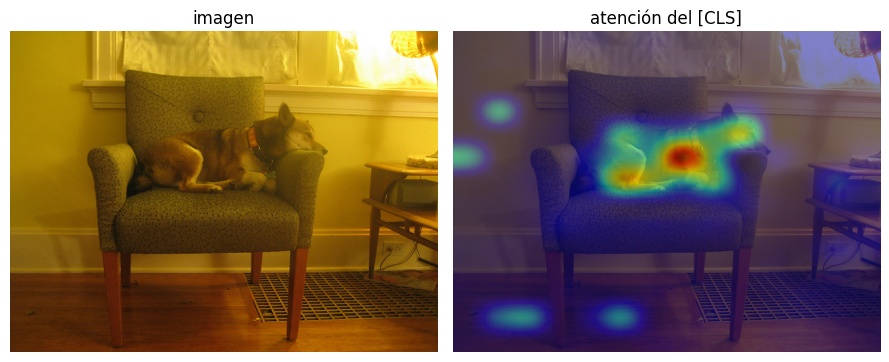

El [CLS] concentra su atención en los objetos relevantes — sin que nadie se lo enseñara.


In [ ]:
# Visualizar la atención del token [CLS] hacia los parches (última capa, promedio de cabezas)
att = out.attentions[-1][0]           # (heads, tokens, tokens)
cls_att = att.mean(0)[0, 1:]          # atención del CLS hacia los 196 parches
grid = int(cls_att.numel() ** 0.5)    # 14x14
mapa = cls_att.reshape(grid, grid).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img_pil); ax[0].set_title("imagen"); ax[0].axis("off")
ax[1].imshow(img_pil); ax[1].imshow(
    np.array(Image.fromarray((mapa/mapa.max()*255).astype("uint8")).resize(img_pil.size)),
    cmap="jet", alpha=0.5)
ax[1].set_title("atención del [CLS]"); ax[1].axis("off")
plt.tight_layout(); plt.show()
print("El [CLS] concentra su atención en los objetos relevantes — sin que nadie se lo enseñara.")

### 🧩 Ejercicio — Reto
1. En el **mini-ViT**, prueba a cambiar `patch` (p. ej. 4 vs 7 vs 14). ¿Cómo afecta al número de tokens y a la accuracy?
2. Elimina el positional embedding (`self.pos`). ¿Empeora? ¿Por qué? (Pista: Clase 1, Bloque 4.)
3. Con el **ViT preentrenado**, prueba tu propia imagen (súbela a Colab) y visualiza su atención.

In [ ]:
# TODO: tu solución
...

## Cierre

El **mismo** Transformer que procesa texto procesa imágenes: basta trocearlas en **parches**. Vimos el pipeline del **ViT**, por qué necesita **más datos** que una CNN (menos sesgo inductivo), sus mejoras (**regularización, destilación**) y el ViT **jerárquico (Swin)** con *window attention*. En la práctica implementaste el *patch embedding*, entrenaste un mini-ViT y viste cómo un ViT preentrenado **atiende a los objetos** por sí solo.

- **Clase 4 — Multimodal + auto-supervisado:** conectar visión y lenguaje (**CLIP**, BLIP, LLaVA), generación con **difusión**, y las **fronteras** del aprendizaje auto-supervisado (DINO, SAM, JEPA).